In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [2]:
orders = pd.read_csv(RAW_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv")
customers = pd.read_csv(RAW_DIR / "olist_customers_dataset.csv")
reviews = pd.read_csv(RAW_DIR / "olist_order_reviews_dataset.csv")
payments = pd.read_csv(RAW_DIR / "olist_order_payments_dataset.csv")

In [3]:
# Chuyển đổi thời gian
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])



In [4]:
print("\n1. QUAN HỆ GIỮA CÁC BẢNG DỮ LIỆU")
# Kiểm tra các khóa chính và khóa ngoại
print(f"Orders: {len(orders):,} đơn hàng")
print(f"Customers: {len(customers):,} khách hàng")
print(f"Order_items: {len(order_items):,} items")
print(f"Reviews: {len(reviews):,} reviews")
print(f"Payments: {len(payments):,} payments")


1. QUAN HỆ GIỮA CÁC BẢNG DỮ LIỆU
Orders: 99,441 đơn hàng
Customers: 99,441 khách hàng
Order_items: 112,650 items
Reviews: 99,224 reviews
Payments: 103,886 payments


In [5]:
# Join các bảng
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(order_items.groupby('order_id')['price'].sum().reset_index(), on='order_id', how='left')
df = df.merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
df = df.merge(reviews.groupby('order_id')['review_score'].mean().reset_index(), on='order_id', how='left')

print(f"\nSau khi merge: {len(df):,} orders với đầy đủ thông tin")


Sau khi merge: 99,441 orders với đầy đủ thông tin


In [20]:
print("\n2. PHÂN TÍCH LẦN MUA ĐẦU TIÊN")
# Lọc các đơn hàng hợp lệ (đã giao hoặc đã ship, tránh đơn bị hủy)
valid_orders = orders[orders['order_status'].isin(['delivered', 'shipped'])].copy()
# JOIN để lấy customer_unique_id cho mỗi đơn hàng
order_customer = pd.merge(
    valid_orders[['order_id', 'customer_id', 'order_purchase_timestamp']], 
    customers[['customer_id', 'customer_unique_id']], 
    on='customer_id', 
    how='inner'
)

# Tìm ngày mua đầu tiên của từng khách hàng duy nhất
first_purchase = order_customer.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'first_purchase_time']

# Tích hợp lại vào bảng order_customer để biết đơn hàng nào là đơn hàng đầu tiên
order_customer = pd.merge(order_customer, first_purchase, on='customer_unique_id', how='left')
order_customer['num_orders'] = order_customer['order_purchase_timestamp'] == order_customer['first_purchase_time']

# Lọc ra danh sách các order_id là đơn đầu tiên
first_orders_only = (order_customer['num_orders'] == True).sum()

print(f"\nKhách hàng chỉ mua 1 lần: {first_orders_only:,} ({first_orders_only/len(order_customer)*100:.1f}%)")


2. PHÂN TÍCH LẦN MUA ĐẦU TIÊN

Khách hàng chỉ mua 1 lần: 94,667 (97.0%)


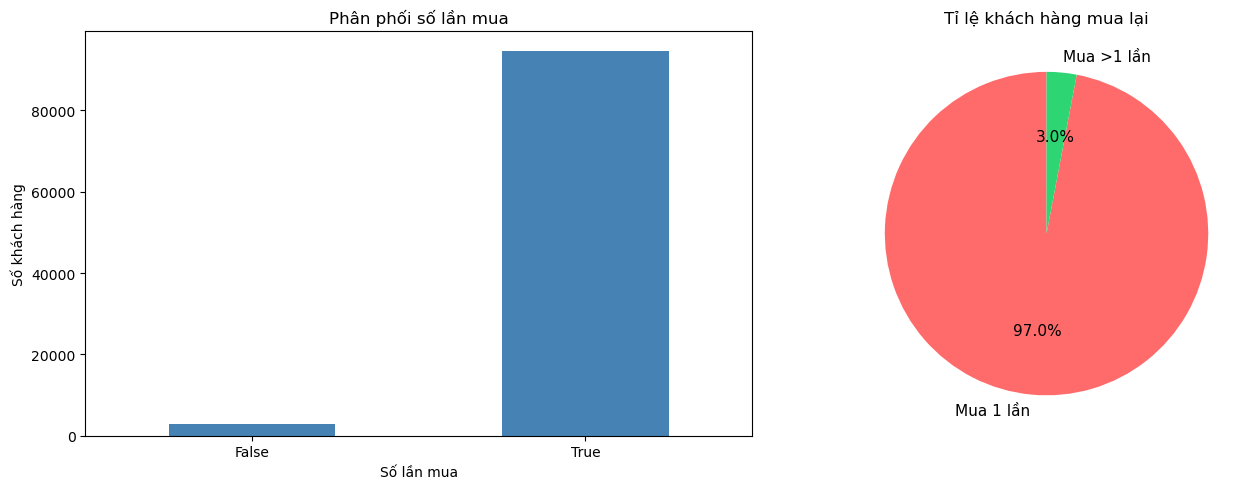

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart số lần mua
(
    order_customer['num_orders']
    .value_counts()
    .sort_index()
    .head(20)
    .plot(
        kind='bar',
        ax=axes[0],
        color='steelblue'
    )
)

axes[0].set_title('Phân phối số lần mua')
axes[0].set_xlabel('Số lần mua')
axes[0].set_ylabel('Số khách hàng')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
labels = ['Mua 1 lần', 'Mua >1 lần']
sizes = [
    first_orders_only,
    len(order_customer) - first_orders_only
]
axes[1].pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff6b6b', '#2ed573'],
    textprops={'fontsize': 11}
)

axes[1].set_title('Tỉ lệ khách hàng mua lại')

plt.tight_layout()
plt.show()

#### Nhật xét 
##### Ta thấy cái chỉ số của bộ data này chỉ Con số 97.0% khách hàng chỉ mua 1 lần (chỉ có 3.0% quay lại mua lần thứ 2) rất khó tìm hiểu churn trong này


3. ĐỊNH NGHĨA CHURN


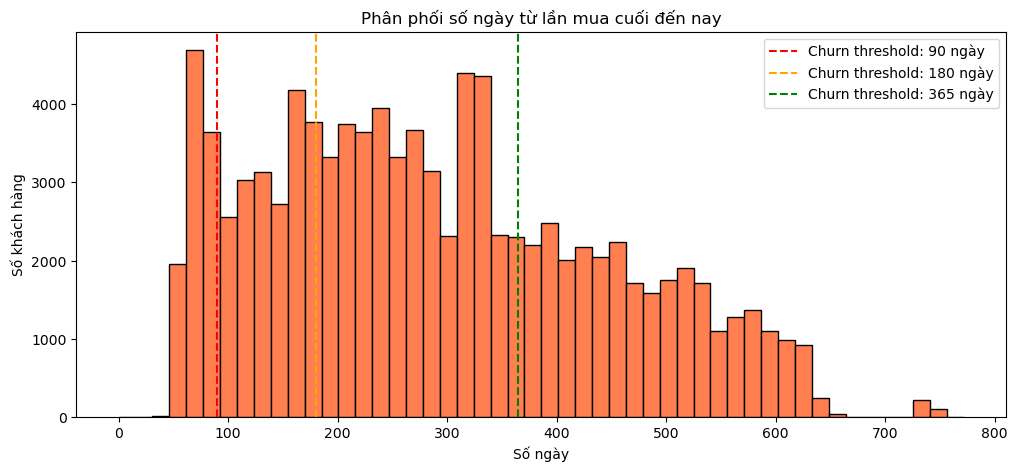

Churn rate với ngưỡng 30 ngày: 100.0%
Churn rate với ngưỡng 60 ngày: 98.3%
Churn rate với ngưỡng 90 ngày: 90.2%
Churn rate với ngưỡng 180 ngày: 71.4%
Churn rate với ngưỡng 365 ngày: 30.1%


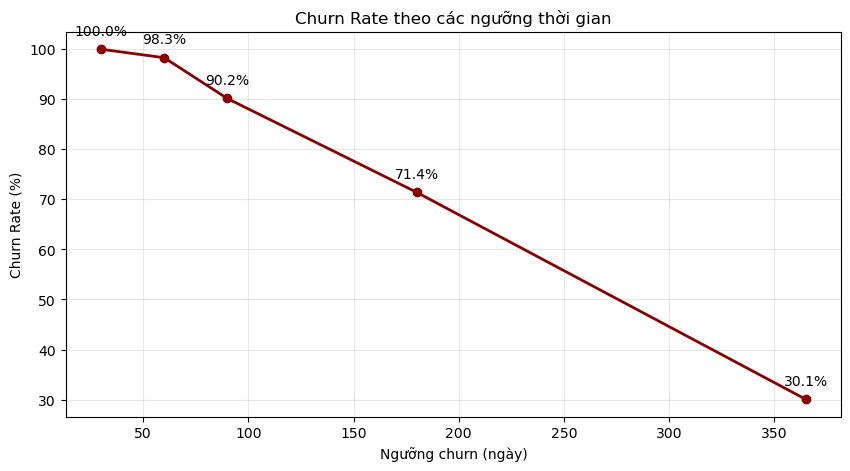


Chọn ngưỡng CHURN = 90 ngày
Tỉ lệ churn: 90.2%


In [24]:
# 3. ĐỊNH NGHĨA CHURN

print("\n3. ĐỊNH NGHĨA CHURN")

# Tìm ngày mua cuối cùng của mỗi khách hàng
last_purchase = df.groupby('customer_id')['order_purchase_timestamp'].max().reset_index()
last_purchase.columns = ['customer_id', 'last_purchase_date']

# Tính số ngày từ lần mua cuối đến ngày cuối của dataset
end_date = df['order_purchase_timestamp'].max()
last_purchase['days_since_last_purchase'] = (end_date - last_purchase['last_purchase_date']).dt.days

# Phân phối thời gian từ lần mua cuối
plt.figure(figsize=(12, 5))
plt.hist(last_purchase['days_since_last_purchase'], bins=50, color='coral', edgecolor='black')
plt.axvline(x=90, color='red', linestyle='--', label='Churn threshold: 90 ngày')
plt.axvline(x=180, color='orange', linestyle='--', label='Churn threshold: 180 ngày')
plt.axvline(x=365, color='green', linestyle='--', label='Churn threshold: 365 ngày')
plt.title('Phân phối số ngày từ lần mua cuối đến nay')
plt.xlabel('Số ngày')
plt.ylabel('Số khách hàng')
plt.legend()
plt.show()

# Định nghĩa Churn với các ngưỡng khác nhau
thresholds = [30, 60, 90, 180, 365]
churn_rates = []

for t in thresholds:
    churned = (last_purchase['days_since_last_purchase'] > t).sum()
    churn_rate = churned / len(last_purchase) * 100
    churn_rates.append(churn_rate)
    print(f"Churn rate với ngưỡng {t} ngày: {churn_rate:.1f}%")

# Vẽ churn rate theo ngưỡng
plt.figure(figsize=(10, 5))
plt.plot(thresholds, churn_rates, marker='o', linewidth=2, color='darkred')
plt.title('Churn Rate theo các ngưỡng thời gian')
plt.xlabel('Ngưỡng churn (ngày)')
plt.ylabel('Churn Rate (%)')
plt.grid(True, alpha=0.3)
for i, (t, rate) in enumerate(zip(thresholds, churn_rates)):
    plt.annotate(f'{rate:.1f}%', (t, rate), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

# Chọn ngưỡng 90 ngày làm churn definition
churn_threshold = 90
df['is_churned'] = (last_purchase['days_since_last_purchase'] > churn_threshold).values

print(f"\nChọn ngưỡng CHURN = {churn_threshold} ngày")
print(f"Tỉ lệ churn: {churn_rates[thresholds.index(churn_threshold)]:.1f}%")

In [ ]:
# 4. ĐẶC ĐIỂM CỦA KHÁCH HÀNG CHURN
print("\n4. ĐẶC ĐIỂM KHÁCH HÀNG CHURN VS ACTIVE")
print("-"*40)

# Thêm thông tin churn vào dataframe
df['is_churned'] = df['customer_id'].map(last_purchase.set_index('customer_id')['days_since_last_purchase']) > churn_threshold

# So sánh đặc điểm
churn_analysis = df.groupby('is_churned').agg({
    'payment_value': 'mean',
    'review_score': 'mean',
    'num_orders': 'mean',
    'customer_id': 'count'
}).round(2)

churn_analysis.columns = ['Avg_Order_Value', 'Avg_Review_Score', 'Avg_Num_Orders', 'Customer_Count']
print(churn_analysis)

# Vẽ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Avg_Order_Value', 'Avg_Review_Score', 'Avg_Num_Orders']
titles = ['Giá trị đơn hàng TB', 'Điểm đánh giá TB', 'Số lần mua TB']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    churn_analysis[metric].plot(kind='bar', ax=axes[i], color=['#2ed573', '#ff6b6b'])
    axes[i].set_title(title)
    axes[i].set_xlabel('Churn Status')
    axes[i].set_xticklabels(['Active', 'Churned'], rotation=0)
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()
